In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set(style="whitegrid")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


Using: cuda


In [ ]:
print("Loading TamilMixSentiment dataset...")

try:
    from datasets import load_dataset
    ds = load_dataset("tamilmixsentiment")
    ds = ds["train"]
except:
    url = "https://raw.githubusercontent.com/bharathichezhiyan/TamilMixSentiment/master/tamilmixsentiment_train.csv"
    df = pd.read_csv(url, sep="\t", names=["label", "text"])
    ds = Dataset.from_pandas(df)

label_map = {
    "positive":0, "pos":0, "0":0, 0:0,
    "negative":1, "neg":1, "1":1, 1:1,
    "mixed_feelings":2, "mixed":2, "2":2, 2:2,
    "unknown_state":3, "unknown":3, "3":3, 3:3,
    "not-tamil":4, "not tamil":4, "4":4, 4:4,
}

def clean(x):
    label = str(x["label"]).lower().strip()
    return {
        "text": x["text"],
        "label": label_map.get(label, 3)
    }

ds = ds.map(clean)

df_full = ds.to_pandas().dropna().reset_index(drop=True)
df_full["label"] = df_full["label"].astype(int)

print(df_full["label"].value_counts())


Loading TamilMixSentiment dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/507k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/60.3k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/11335 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1260 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3149 [00:00<?, ? examples/s]

Map:   0%|          | 0/11335 [00:00<?, ? examples/s]

label
0    7627
1    1448
2    1283
3     609
4     368
Name: count, dtype: int64


In [ ]:
MODEL_NAME = "xlm-roberta-base"
MAX_LEN = 160  # XLM-R performs better with slightly longer sequences

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
    )


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []
all_fold_preds = []
all_fold_labels = []

label_names = ["Positive", "Negative", "Mixed", "Unknown", "Not-Tamil"]
num_labels = 5


In [ ]:
def compute_metrics(output):
    logits, labels = output
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

fold = 0

for train_idx, val_idx in skf.split(df_full["text"], df_full["label"]):
    fold += 1
    print(f"\n=========== FOLD {fold}/{k} ===========")

    set_seed(42 + fold)

    train_df = df_full.iloc[train_idx]
    val_df   = df_full.iloc[val_idx]

    train_ds = Dataset.from_pandas(train_df)
    val_ds   = Dataset.from_pandas(val_df)

    train_tok = train_ds.map(preprocess, batched=True)
    val_tok   = val_ds.map(preprocess, batched=True)

    train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels
    ).to(device)

    # UNIVERSAL TrainingArguments (compatible with any TF version)
    try:
        args = TrainingArguments(
            output_dir=f"./xlmr_kfold/fold{fold}",
            eval_strategy="epoch",
            logging_strategy="epoch",
            save_strategy="no",
            learning_rate=2e-5,
            per_device_train_batch_size=8,   # XLM-R is heavier
            per_device_eval_batch_size=16,
            num_train_epochs=4,
            weight_decay=0.01,
            warmup_ratio=0.1,
            report_to="none",
        )
    except:
        args = TrainingArguments(
            output_dir=f"./xlmr_kfold/fold{fold}",
            evaluation_strategy="epoch",
            logging_steps=100,
            learning_rate=2e-5,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=16,
            num_train_epochs=4,
            weight_decay=0.01,
            report_to="none",
        )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        compute_metrics=compute_metrics
    )

    trainer.train()

    # Fold Evaluation
    results = trainer.evaluate()
    acc = results["eval_accuracy"]
    print(f"Fold {fold} Accuracy = {acc:.4f}")
    fold_accuracies.append(acc)

    preds = trainer.predict(val_tok)
    all_fold_preds.append(np.argmax(preds.predictions, axis=1))
    all_fold_labels.append(preds.label_ids)



=========== FOLD 1/5 ===========


Map:   0%|          | 0/9068 [00:00<?, ? examples/s]

Map:   0%|          | 0/2267 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Map:   0%|          | 0/9068 [00:00<?, ? examples/s]

Map:   0%|          | 0/2267 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.078700,0.981894,0.678871
2,0.933000,0.921545,0.688134
3,0.865200,0.958632,0.683282
4,0.802000,0.952106,0.676665


Fold 5 Accuracy = 0.6767



======= FINAL 5-FOLD RESULTS =======
Fold Accuracies: [0.6908, 0.6811, 0.6859, 0.6903, 0.6767]
Mean Accuracy: 0.685

Classification Report:
              precision    recall  f1-score   support

    Positive       0.74      0.92      0.82      7627
    Negative       0.34      0.31      0.32      1448
       Mixed       0.00      0.00      0.00      1283
     Unknown       0.24      0.03      0.06       609
   Not-Tamil       0.68      0.71      0.70       368

    accuracy                           0.68     11335
   macro avg       0.40      0.40      0.38     11335
weighted avg       0.57      0.68      0.62     11335



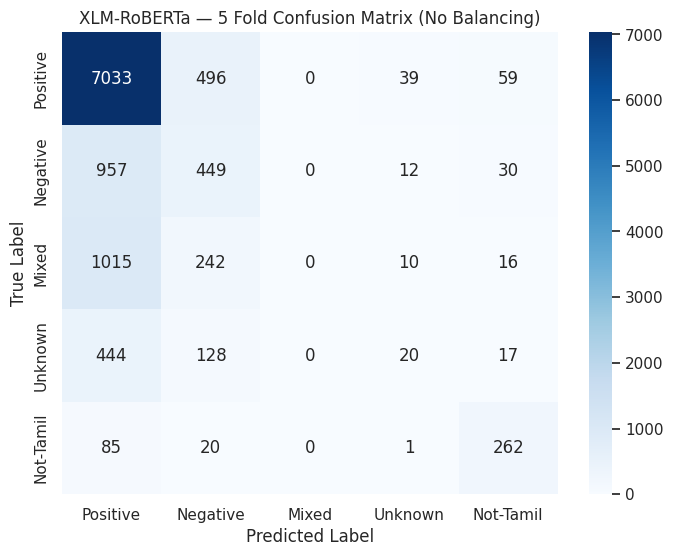

In [ ]:
all_preds = np.concatenate(all_fold_preds)
all_labels = np.concatenate(all_fold_labels)

print("\n======= FINAL 5-FOLD RESULTS =======")
print("Fold Accuracies:", [round(x,4) for x in fold_accuracies])
print("Mean Accuracy:", round(np.mean(fold_accuracies), 4))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_names, yticklabels=label_names
)
plt.title("XLM-RoBERTa — 5 Fold Confusion Matrix (No Balancing)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()
